# Name
Please write your name down here:

Peter Brederlow

**Differential expression analysis**

We will move on to another set of quantitative techniques: differential gene expression analysis. Our goal will be to find diet-associated changes in the mice's transcriptome.

Yesterday we were looking for genotype associated changes in continuous phenotypes. Conceptually, today's material isn't too different: we will continue to analyze the association between a categorical condition (CD/HFD diet) with continuous outcomes (gene expression levels) but we will do it on larger scale data of homogenous nature.

For some more information on and examples of the plot types we will use here, see:<br>
http://www.arrayanalysis.org/main.html

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.sandbox.stats.multicomp import multipletests

# Download the gene expression data

Either download the aad0189_DataFileS5.xlsx from the [supplementary material](https://www.science.org/doi/10.1126/science.aad0189#supplementary-materials) or use the GitHub link: `https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/Introduction/refs/heads/main/data/expression.xlsx` to get the gene expression data.

## Read in aad0189_DataFileS5.xlsx with pandas
Open the spreadsheet in Excel beforehand. Notice that the headers aren't in the first row, so use the `header` keyword to specify the header's line number for `read_excel()`.
Save the file as `data`.

In [2]:
# YOUR CODE HERE
url = 'https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/Introduction/refs/heads/main/data/expression.xlsx'
data = pd.read_excel(url, index_col=0, skiprows=2)

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
assert 'data' in locals()

## Calculate gene-wise average expression values, and clean up

The expression of many genes were measured by multiple probes on the microarray. We would like to reduce the complexity of the data, and have only one, averaged expression row per gene. You can use the `groupby` function to achieve this, but make sure to use the `Gene.1` column instead of `Gene`. They are identical for the majority of rows, but `Gene.1` will be better for us later.

The expression values are stored in the columns that contain the string `Liver`, so use the `filter` method to keep only those columns. Finally, remove that `_Liver` substring from the column names. Call the resulting dataframe `expr`.

In [4]:
# YOUR CODE HERE
data.index = data['Gene.1']
expr = data.filter(like='Liver').groupby(data.index).mean()
expr.columns = expr.columns.str.replace('_Liver', '', regex=False)
expr


,C57BL/6J_CD,DBA/2J_CD,BXD43_CD,BXD44_CD,BXD45_CD,BXD48_CD,BXD49_CD,BXD51_CD,BXD55_CD,BXD56_CD,...,BXD89_HFD,BXD90_HFD,BXD95_HFD,BXD96_HFD,BXD97_HFD,BXD98_HFD,BXD99_HFD,BXD100_HFD,BXD101_HFD,BXD103_HFD
Gene.1,,,,,,,,,,,,,,,,,,,,,
544988,6.1830,6.353333,6.262333,6.263667,6.270,6.201333,6.2370,6.274667,6.319,6.2710,...,6.364333,6.339333,6.397667,6.3280,6.280333,6.385333,6.460667,6.331667,6.216667,6.278333
100043387,10.3840,9.848000,10.108000,9.860000,9.392,9.926000,10.1050,10.040000,10.128,9.4100,...,10.088000,10.553000,9.556000,10.6320,10.427000,10.217000,10.140000,10.639000,10.223000,9.956000
0610007C21Rik,12.3890,12.559000,12.647000,12.639000,12.515,12.659000,12.5710,12.512000,12.651,12.5290,...,12.608000,12.593000,12.792000,12.5730,12.690000,12.700000,12.628000,12.550000,12.660000,12.696000
0610007L01Rik,10.2875,10.390000,10.411000,10.419500,10.306,10.432000,10.2005,10.432000,10.320,10.2945,...,10.280000,10.309000,10.466500,10.1370,10.122000,10.179500,10.370000,10.275000,10.048000,10.154500
0610007P08Rik,8.1160,8.422000,8.235000,8.135000,8.198,8.092500,8.1460,7.876500,8.400,8.0930,...,8.265500,8.275500,7.796000,8.2495,8.297000,8.058000,7.978000,8.148500,8.191000,8.272000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zzz3,10.1750,10.361000,10.231000,10.146000,10.261,10.331000,10.6900,10.334000,10.336,10.2200,...,10.079000,10.213000,10.133000,10.2700,10.333000,10.179000,10.075000,10.090000,10.108000,10.182000
a,6.9390,7.398000,7.447000,7.552000,7.600,7.744000,7.1580,7.310000,7.088,7.6100,...,7.727000,7.143000,7.683000,7.1850,7.036000,7.074000,7.513000,7.241000,7.226000,7.283000
l7Rn6,9.8850,9.945000,10.123000,9.319000,9.510,9.606000,9.8760,9.898000,9.786,9.8380,...,9.853000,10.096000,9.626000,9.9960,9.947000,9.992000,9.916000,9.907000,9.918000,9.748000


In [5]:
assert 'expr' in locals()

# Inspecting data consistency and normalization
## Create a ratio-intensity plot a.k.a. MA plot
The ratio intensity plot compares two microarrays with each other to detect systematic calibration differences between them, and therefore it's an important tool for microarray normalization. When we have so many microarrays (80+ in this case) it is practical to take one as the reference, and compare + normalize the rest against it. For simplicity, we will just compare a single pair now -- the rest would be the same.

Pick any two microarray measurements (columns) from the `expr` DataFrame.

The ratio intensity plot shows the log2 expression ratio of each pair of corresponding probes as a function of their expression (light intensity) on a scatter plot. Since the data you're working with has already been log2-transformed (common practice in microarray experiments) the "ratio" is in fact the *difference* of the values, since log(x1/x2) = log(x1)-log(x2).

Depending on your computer, the scatter plot may take a while to draw, so you can cheat a bit and plot only every 10th data point. You can use `.iloc[::10]` to achieve this.

You should also add a reference line at zero, and a (fancy kind of) rolling average of the points using `nonparametric.lowess` from the module `statsmodels.api` (already imported as `sm`).

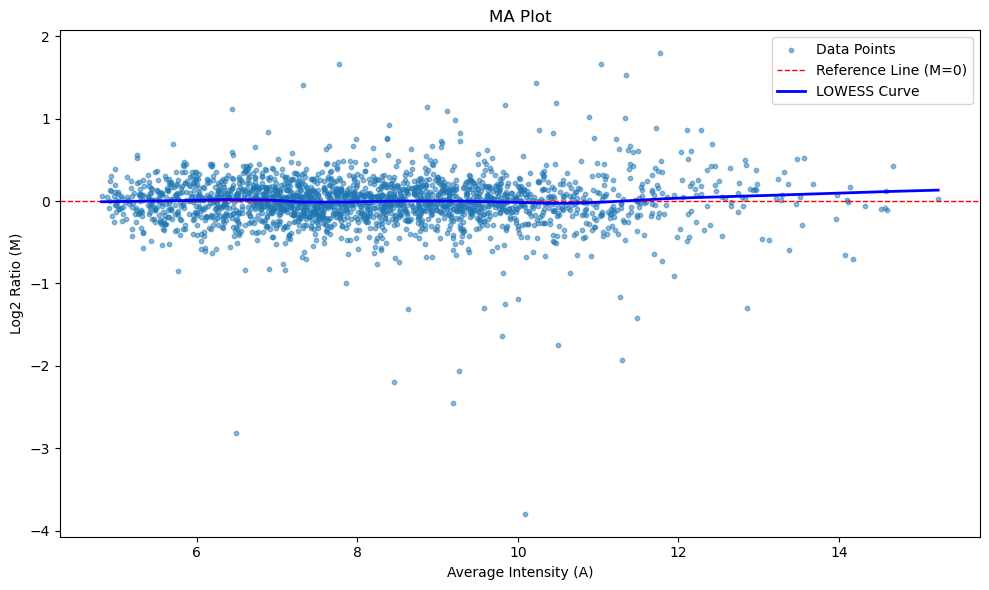

In [6]:
# YOUR CODE HERE
ratio_intensity = expr['DBA/2J_CD'] - expr['BXD43_CD']
#ratio_intensity = expr.iloc[:,0] - expr.iloc[:,1]
average_intensity = (expr['DBA/2J_CD'] + expr['BXD43_CD']) / 2
#average_intensity = expr.iloc[:,0] + expr.iloc[:,1] / 2
subset_M = ratio_intensity.iloc[::10]
subset_A = average_intensity.iloc[::10]

# Create the MA plot
plt.figure(figsize=(10, 6))
plt.scatter(subset_A, subset_M, alpha=0.5, s=10, label='Data Points')
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Reference Line (M=0)')
lowess = sm.nonparametric.lowess(subset_M, subset_A, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='blue', linewidth=2, label='LOWESS Curve')
plt.xlabel('Average Intensity (A)')
plt.ylabel('Log2 Ratio (M)')
plt.title('MA Plot')
plt.legend()
plt.tight_layout()
plt.show()

## Implement a Relative Log Expression (RLE) box plot
The Relative Log Expression (RLE) values are the log2-ratios of individual gene expression values versus the median expression of the gene across all experiments. (Reminder once again: the expression values are log2-transformed, so their ratio means difference in practice).

It is assumed that most genes are not systematically over- or underexpressed across the arrays, so we expect these log2-ratios to be centered around 0 for every array, with similar standard deviations.

By creating a box-plot out of the RLE values for every array, we can get visual confirmation whether this is the case, and the arrays had been normalized consistently.

/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_78398/1313922628.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(RLE.values, labels=RLE.columns, flierprops=flierprops)


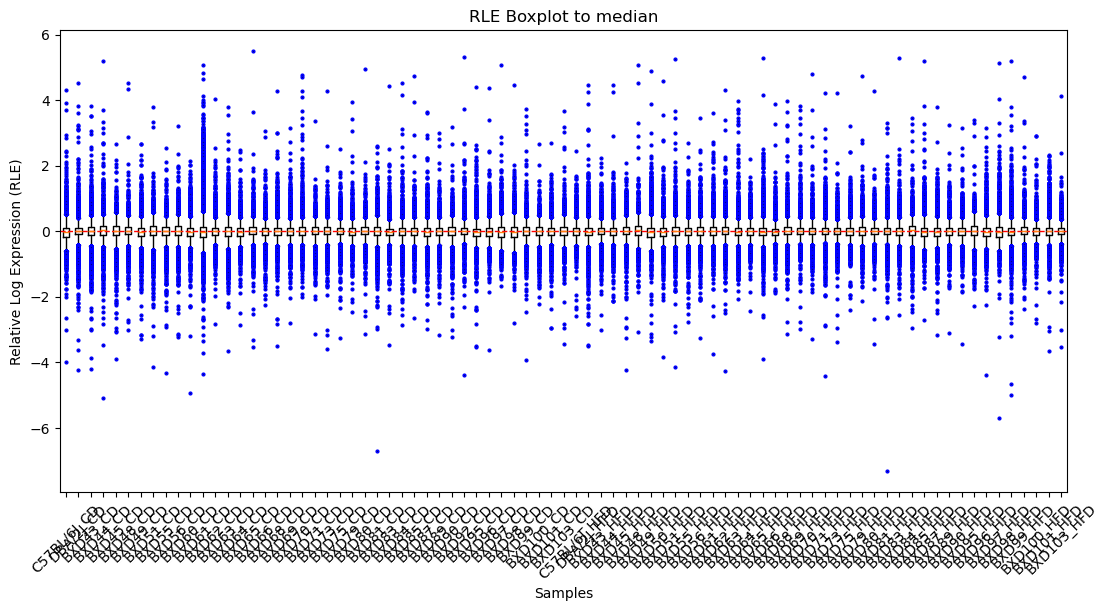

In [7]:
# YOUR CODE HERE
medians = expr.median(axis=1) 
RLE = expr.subtract(medians, axis=0)
flierprops = dict(marker='o', markersize=2, linestyle='none', markerfacecolor='darkblue', markeredgecolor='blue')

plt.figure(figsize=(13, 6))
plt.boxplot(RLE.values, labels=RLE.columns, flierprops=flierprops)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Samples')
plt.ylabel('Relative Log Expression (RLE)')
plt.title('RLE Boxplot to median')
plt.xticks(rotation=45)
plt.show()

/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_78398/3602779197.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(RLE.values, labels=RLE.columns, flierprops=flierprops)


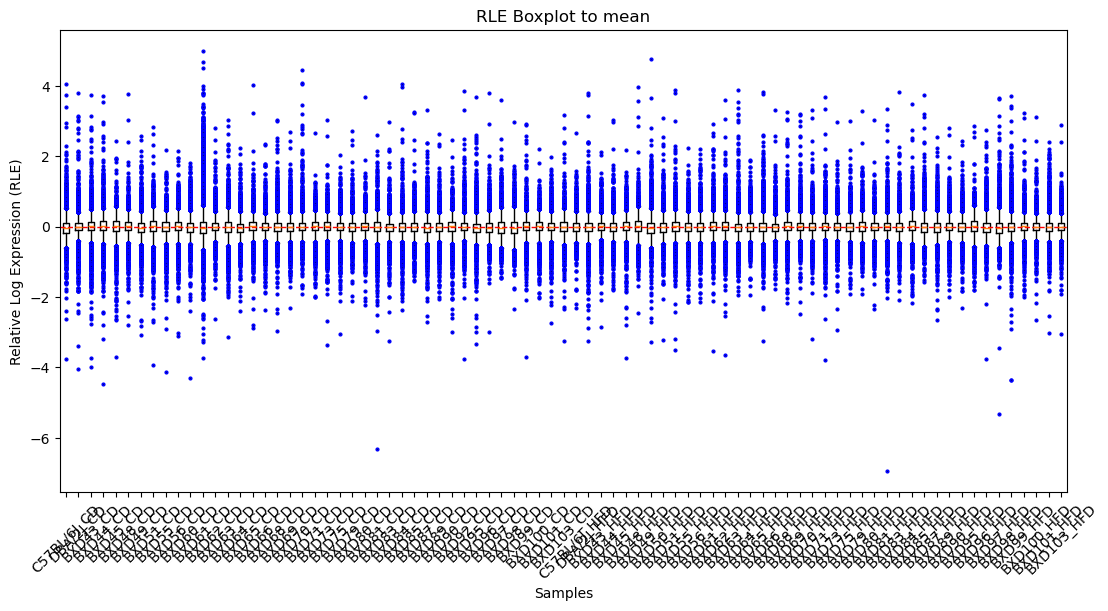

In [8]:
# YOUR CODE HERE
medians = expr.mean(axis=1) 
RLE = expr.subtract(medians, axis=0)
flierprops = dict(marker='o', markersize=2, linestyle='none', markerfacecolor='darkblue', markeredgecolor='blue')

plt.figure(figsize=(13, 6))
plt.boxplot(RLE.values, labels=RLE.columns, flierprops=flierprops)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Samples')
plt.ylabel('Relative Log Expression (RLE)')
plt.title('RLE Boxplot to mean')
plt.xticks(rotation=45)
plt.show()

## Do you consider it necessary to perform a quantile normalization for the microarrays?

**Are there any strains with systematically higher or lower expression values than the rest?**

The medians do not differ, and pretty much all of them are centered around the mean. What differs quite drastically is the spread of the data, this would also be accounted for by quantile normalization, but might also be sample specific. Since the medians are mroe robust to outliers, and we are interested in a change of the mean expression, one could argue to do quantile normalization. Since the means again show little to no change in the RLE boxplot on the mean normalied data, so I would argue against quantile norm.

# Which statistical test to choose?
We want to infer differentially expressed genes between the CD and the HFD condition. Therefore we treat the expression values of all the strains for a given gene under one diet as independent observations of the same random variable (i.e. we ignore variation caused by genetics and focus on variation caused by the diet). We then compare these distributions between the two diets with a statistical test to see whether their means differ significantly or not.

Since most statistical tests assume certain properties of the compared distributions, we'll first have to find out which of these assumptions are true for our data. This way we can choose a suitable test for differential expression detection. We will limit ourselves to the following mean-equality tests:

* Student's t-test (assumes distributions are normally distributed and have equal variance, has highest statistical power)
* Welch's t-test (assumes normal distribution, does not assume equal variance, slightly lower statistical power) 
* Mann-Whitney U-test or its matched-samples equivalent Wilcoxon's rank-sum test (no assumptions about the tested distributions, weakest statistical power)

## Separate the CD and HFD samples in the expression DataFrame
Since you will have to compare expression values of CD samples with those from HFD samples, you have to be able to access them separately. You can reuse the `split_cd_hfd` function from before, and store the resulting DataFrame in `expr2`. **How many samples did we lose?** We will accept this trade-off for simplicity now.

Remember why the diet-inclusive MultiIndex is useful: if you ever need to extract the CD or HFD samples into a separate DataFrames, you can always do it with the cross-section opreator: `expr2_cd = expr2.xs('CD', level='diet')`. And if you want to revert to the original layout, you can do `expr2.unstack()`.

In [9]:
# YOUR CODE HERE
expr.index.name = "gene"
def split_cd_hfd(df):
    df.index.name = "gene"
    only_cd = df.loc[:, df.columns.str.contains(r"(_CD$)", na =False)]
    only_hfd = df.loc[:, df.columns.str.contains(r"(_HFD$)", na =False)]
    
    only_cd.columns = only_cd.columns.str.replace(r"(_CD$)", "", regex=True)
    only_hfd.columns = only_hfd.columns.str.replace(r"(_HFD$)", "", regex = True)
    
    only_cd.insert(0, "diet", "CD")
    only_hfd.insert(0, "diet", "HFD")

    shared_cols = only_cd.columns.intersection(only_hfd.columns)
    only_cd = only_cd[shared_cols]
    only_hfd = only_hfd[shared_cols]
    
    combined = pd.concat([only_cd, only_hfd])
    combined = combined.reset_index()
    combined = combined.sort_values(by=["gene", "diet"])
    combined = combined.set_index(["gene", "diet"])
    combined.columns.name = "experiment"
    return combined
expr2 = split_cd_hfd(expr)
expr2

/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_78398/627350448.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  only_cd = df.loc[:, df.columns.str.contains(r"(_CD$)", na =False)]
/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_78398/627350448.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  only_hfd = df.loc[:, df.columns.str.contains(r"(_HFD$)", na =False)]


experiment           C57BL/6J     DBA/2J      BXD43      BXD44      BXD45  \
gene          diet                                                          
544988        CD     6.183000   6.353333   6.262333   6.263667   6.270000   
              HFD    6.365333   6.348333   6.301333   6.345667   6.350667   
100043387     CD    10.384000   9.848000  10.108000   9.860000   9.392000   
              HFD   10.215000  10.153000  10.361000  10.044000   9.736000   
0610007C21Rik CD    12.389000  12.559000  12.647000  12.639000  12.515000   
...                       ...        ...        ...        ...        ...   
l7Rn6         HFD    9.950000  10.169000  10.146000   9.376000   9.857000   
mCG_21548     CD     7.335000   7.801000   7.789000   7.708000   7.703000   
              HFD    7.634000   7.720000   7.851000   7.811000   7.968000   
rp9           CD     9.943000   9.795000   9.860000   9.715000   9.772000   
              HFD    9.811000   9.743000   9.765000   9.804000   9.683000   

experiment              BXD48      BXD49      BXD51      BXD55      BXD56  \
gene          diet                                                          
544988        CD     6.201333   6.237000   6.274667   6.319000   6.271000   
              HFD    6.285667   6.207667   6.362667   6.474667   6.427333   
100043387     CD     9.926000  10.105000  10.040000  10.128000   9.410000   
              HFD   10.108000  10.195000  10.155000   9.979000   9.786000   
0610007C21Rik CD    12.659000  12.571000  12.512000  12.651000  12.529000   
...                       ...        ...        ...        ...        ...   
l7Rn6         HFD    9.813000   9.811000  10.025000  10.012000   9.782000   
mCG_21548     CD     7.677000   7.767000   7.844000   7.933000   7.451000   
              HFD    8.004000   7.537000   7.698000   7.570000   7.695000   
rp9           CD     9.743000   9.951000   9.618000   9.856000   9.658000   
              HFD    9.666000   9.868000   9.581000   9.832000   9.848000   

experiment          ...      BXD89      BXD90      BXD95   BXD96      BXD97  \
gene          diet  ...                                                       
544988        CD    ...   6.300667   6.274667   6.345000   6.283   6.294333   
              HFD   ...   6.364333   6.339333   6.397667   6.328   6.280333   
100043387     CD    ...  10.091000  10.015000  10.484000  10.306  10.306000   
              HFD   ...  10.088000  10.553000   9.556000  10.632  10.427000   
0610007C21Rik CD    ...  12.815000  12.761000  12.473000  12.583  12.441000   
...                 ...        ...        ...        ...     ...        ...   
l7Rn6         HFD   ...   9.853000  10.096000   9.626000   9.996   9.947000   
mCG_21548     CD    ...   7.646000   7.909000   7.654000   7.543   7.419000   
              HFD   ...   7.679000   7.786000   7.753000   7.672   7.664000   
rp9           CD    ...   9.848000   9.887000   9.668000   9.719   9.693000   
              HFD   ...   9.663000   9.943000   9.473000   9.734   9.763000   

experiment              BXD98      BXD99     BXD100     BXD101     BXD103  
gene          diet                                                         
544988        CD     6.268667   6.219000   6.332333   6.432667   6.428333  
              HFD    6.385333   6.460667   6.331667   6.216667   6.278333  
100043387     CD    10.438000  10.063000  10.260000   9.832000   9.898000  
              HFD   10.217000  10.140000  10.639000  10.223000   9.956000  
0610007C21Rik CD    12.612000  12.534000  12.721000  12.661000  12.583000  
...                       ...        ...        ...        ...        ...  
l7Rn6         HFD    9.992000   9.916000   9.907000   9.918000   9.748000  
mCG_21548     CD     7.314000   7.820000   8.143000   7.901000   8.034000  
              HFD    7.721000   7.873000   7.821000   7.541000   7.846000  
rp9           CD     9.959000   9.764000   9.766000   9.732000   9.715000  
              HFD    9.822000   9.693000   9.600000   9.

In [10]:
assert 'expr2' in locals()

We lost 3 samples, that did not have matching CD or HFD measurements.

## Assumption testing: do the CD and HFD samples have equal variance?
We will store the gene `Stradb` in `gene`, so we can reproduce it later.

In [11]:
gene = 'Stradb'

### Use the appropriate statistical test to check whether the samples have equal variance
You have to compare the expression values of this gene between the `CD` and `HFD` measurements. The Levene-test is suitable, and it's implemented in `scipy.stats`. Store the p value in `stradb_p_value`. **How do you interpret its output p-value?**

In [12]:
# YOUR CODE HERE
stradb_p_value = stats.levene(expr2.loc[gene, 'CD'], expr2.loc[gene, 'HFD']).pvalue
stradb_p_value

np.float64(0.6650713185995359)

In [13]:
assert 'stradb_p_value' in locals()

The null hypothesis of the test is, that the variances is equal in both genes, so it assumes homoscedasticity between samples. This cannot be rejected with a p-value of 0.665, and hence we can assume equal variances.

## Perform the test on all genes, and draw a p-value histogram

### To assess the overall situation, run the equal variance test for all genes.
Store the result in `levene_pvals`.

In [14]:
# YOUR CODE HERE
expr_hfd = expr2.xs('HFD', level='diet')
expr_cd = expr2.xs('CD', level='diet')
levene_pvals = expr_cd.apply(lambda x: stats.levene(x, expr_hfd.loc[x.name]).pvalue, axis=1)
levene_pvals_corrected = multipletests(levene_pvals, method='fdr_bh')[1]
levene_pvals



gene
544988           0.600144
100043387        0.353129
0610007C21Rik    0.782691
0610007L01Rik    0.292483
0610007P08Rik    0.775178
                   ...   
Zzz3             0.067418
a                0.541478
l7Rn6            0.072936
mCG_21548        0.070963
rp9              0.510190
Length: 21835, dtype: float64

In [15]:
assert 'levene_pvals' in locals()

### Plot the histogram of the raw p-values, and draw a conclusion.
**Can we assume equal variance?**

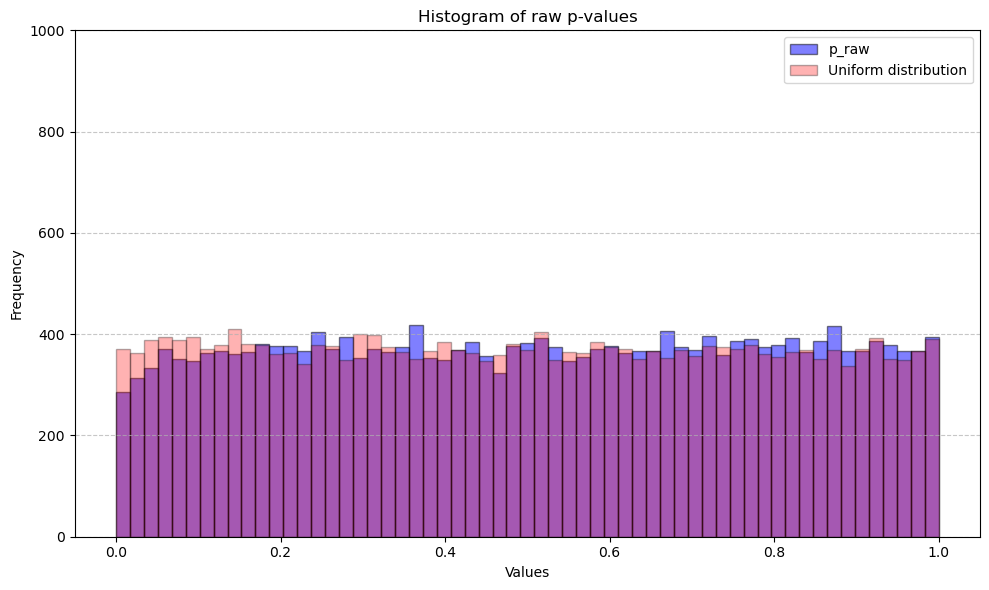

In [16]:
# YOUR CODE HERE
min_value = levene_pvals.min()  
max_value = levene_pvals.max() 
uniform_p_values = np.random.uniform(low=min_value, high=max_value, size=len(levene_pvals))
bins = np.linspace(min_value, max_value, 60)  
plt.figure(figsize=(10, 6))
plt.hist(levene_pvals, bins=bins, color='blue', alpha=0.5, edgecolor='black', label='p_raw')
plt.hist(uniform_p_values, bins=bins, color='red', alpha=0.3, edgecolor='black', label='Uniform distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.ylim(0, 1000)
plt.title('Histogram of raw p-values')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

YOUR ANSWER HERE

### Plot a second histogram of the corrected p-values to find out if you are correct.

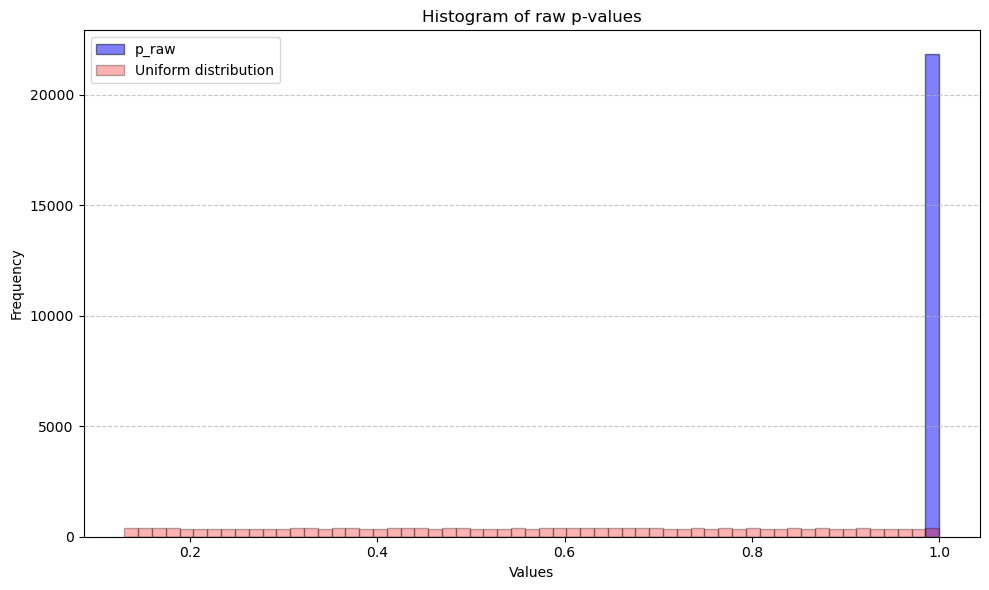

In [17]:
# YOUR CODE HERE
min_value = levene_pvals_corrected.min()  
max_value = levene_pvals_corrected.max() 
uniform_p_values = np.random.uniform(low=min_value, high=max_value, size=len(levene_pvals_corrected))
bins = np.linspace(min_value, max_value, 60)  
plt.figure(figsize=(10, 6))
plt.hist(levene_pvals_corrected, bins=bins, color='blue', alpha=0.5, edgecolor='black', label='p_raw')
plt.hist(uniform_p_values, bins=bins, color='red', alpha=0.3, edgecolor='black', label='Uniform distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of raw p-values')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Assumption testing: are the CD and HFD samples normally distributed?
### Find an appropriate statistical test to answer whether the samples are normally distributed
`scipy.stats` can help you with this one too. First, do it for just one gene, like you did in 2.1.2.

In [18]:
# YOUR CODE HERE
shap = stats.shapiro(expr2.loc[gene, 'CD'])
shap 

ShapiroResult(statistic=np.float64(0.9735857480991388), pvalue=np.float64(0.48015260148129607))

In [19]:
norm = stats.normaltest(expr2.loc[gene, 'CD'])
norm

NormaltestResult(statistic=np.float64(0.8922609174760822), pvalue=np.float64(0.6401002599421909))

Both tests accept their respective null hypothesis, which is normality. Hence, we can assume our data follows a normal distribution for StradB.

### Perform the test on all genes, and draw a p-value histogram

Note that the normality test should be done on the compared sets separately, i.e. check per-gene expression values of CD mice for normality first, and then the same with HFD. Apply multiple testing correction to both results and plot the uncorrected and corrected p-values each by diet. **What does the histogram look like for this one? How does this affect your options?**

In [20]:
# YOUR CODE HERE
norm_pvals = expr2.apply(lambda x: stats.normaltest(x).pvalue, axis=1)
adjusted_pvals = multipletests(norm_pvals, method='fdr_bh')[1]
adjusted_pvals = pd.Series(adjusted_pvals, index=norm_pvals.index)
adjusted_pvals

gene           diet
544988         CD      1.411093e-05
               HFD     9.243590e-01
100043387      CD      3.850877e-01
               HFD     8.265962e-01
0610007C21Rik  CD      9.447178e-01
                           ...     
l7Rn6          HFD     3.321622e-01
mCG_21548      CD      9.711077e-01
               HFD     8.741869e-01
rp9            CD      6.715469e-09
               HFD     1.978064e-01
Length: 43670, dtype: float64

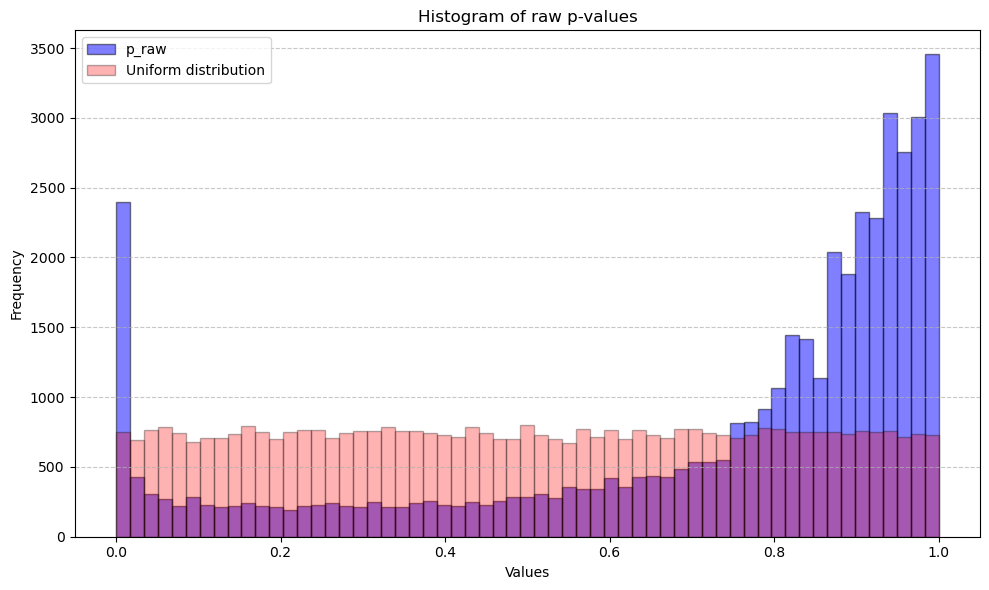

In [21]:
#plot p-value histogram again
min_value = adjusted_pvals.min()  
max_value = adjusted_pvals.max() 
uniform_p_values = np.random.uniform(low=min_value, high=max_value, size=len(adjusted_pvals))
bins = np.linspace(min_value, max_value, 60)  
plt.figure(figsize=(10, 6))
plt.hist(adjusted_pvals, bins=bins, color='blue', alpha=0.5, edgecolor='black', label='p_raw')
plt.hist(uniform_p_values, bins=bins, color='red', alpha=0.3, edgecolor='black', label='Uniform distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of raw p-values')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We have an enrichment of very low p-values, which indicates that a lot of the genes aren't normally distributed. This violates further test assumptions of a lot of parametric tests. 

### In light of the tested assumptions, choose a testing strategy for identifying differences in the expression means of the CD and HFD samples

Don't write code, just find the right test(s), and discuss how you would proceed with the analysis. **Your trade-off is between statistical power and statistical soundness. Can you have the best of both worlds?**

Since our normality assumptions are not fullfilled, we need to use a non parametric test such as the Mann-Whitney U Test to test for differences in the mean. This is the only robust choice, since a Wilcoxon-Ranked Sum-Test assumes dependent samples, such as in a time-series.

# Differential expression testing

Having checked the assumptions that our data fulfill, it's time to settle on a statistical test to compare gene expression values between the CD and HFD conditions.

We would like you to end up with a DataFrame `diffexpr`, which is indexed by gene identifiers, and has at least three columns:
* log2 fold change between CD and HFD means
* raw p-values of the mean-equality test that you chose
* B-H corrected p-values of the test

If you have enough time, you can add the raw and corrected p-values of other mean-equality tests as well, and compare them with each other.

In [22]:
# YOUR CODE HERE
expr_hfd = expr2.xs('HFD', level='diet')
expr_cd = expr2.xs('CD', level='diet')
expr_hfd = expr2.xs('HFD', level='diet')
expr_cd = expr2.xs('CD', level='diet')
diffexpr = pd.DataFrame(index=expr_cd.index)
diffexpr['pval'] = expr_cd.apply(lambda x: stats.mannwhitneyu(x, expr_hfd.loc[x.name]).pvalue, axis=1)
diffexpr['adj_pval'] = multipletests(diffexpr['pval'], method='fdr_bh')[1]
diffexpr['log2_fold_change'] = np.log2(expr_cd.mean(axis=1) / expr_hfd.mean(axis=1))
diffexpr

,pval,adj_pval,log2_fold_change
gene,,,
544988,2.461825e-03,0.007086,-0.009530
100043387,1.588075e-01,0.238169,-0.013465
0610007C21Rik,3.684131e-01,0.468540,-0.001359
0610007L01Rik,9.561658e-01,0.971427,0.001034
0610007P08Rik,4.618156e-02,0.085016,-0.010846
...,...,...,...
Zzz3,9.252459e-07,0.000008,0.021682
a,2.760128e-01,0.372528,-0.011845
l7Rn6,1.454909e-02,0.032398,-0.017959


## Volcano plots
Volcano plots visualize two key aspects of a differential expression experiment at once on a single scatter plot: the significance of differential expression as a function of the log2 fold change between the two conditions.
For a more detailed description:

* https://en.wikipedia.org/wiki/Volcano_plot_(statistics)

### Implement a Volcano plot
Use `matplotlib` instead of `seaborn` for customizability: try to include cut-off lines and highlight significant genes (above the cut-off in statistical significance AND fold change) with a different color. Feel free to introduce an extra column in `diffexpr` if it helps you achieve that.

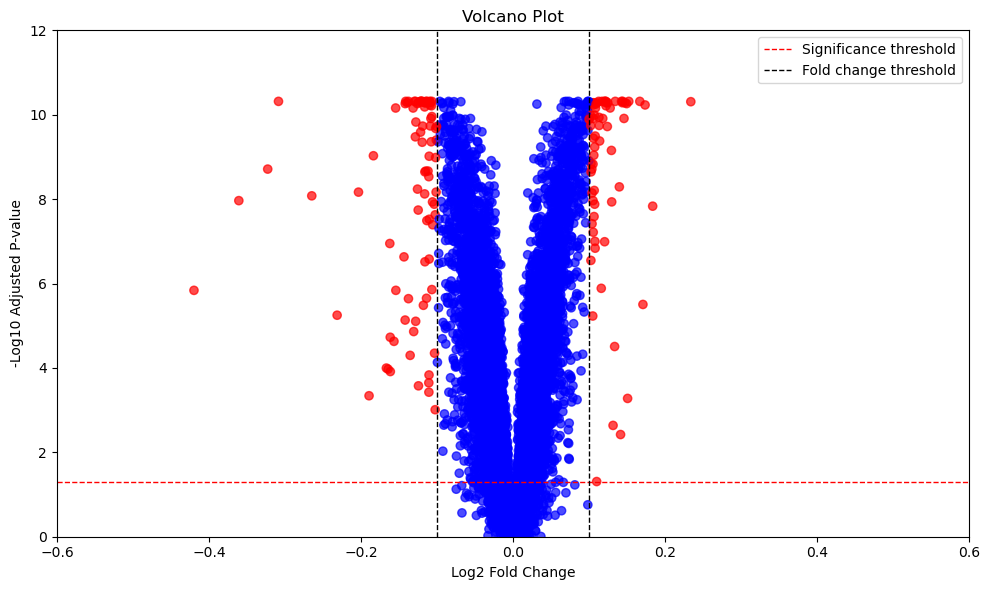

In [23]:
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
significance_threshold = 0.05  
fold_change_threshold = 0.1 
diffexpr['relevant'] = (diffexpr['adj_pval'] < significance_threshold) & (abs(diffexpr['log2_fold_change']) > fold_change_threshold)
plt.scatter(
    diffexpr['log2_fold_change'],
    -np.log10(diffexpr['adj_pval']),
    color=diffexpr['relevant'].map({True: 'red', False: 'blue'}),
    alpha=0.7,
)
plt.axhline(-np.log10(significance_threshold), color='red', linestyle='--', linewidth=1, label='Significance threshold')
plt.axvline(fold_change_threshold, color='black', linestyle='--', linewidth=1, label='Fold change threshold')
plt.axvline(-fold_change_threshold, color='black', linestyle='--', linewidth=1)
plt.xlabel('Log2 Fold Change')
plt.xlim(-0.6, 0.6)
plt.ylabel('-Log10 Adjusted P-value')
plt.ylim(0, 12)
plt.title('Volcano Plot')
plt.legend()
plt.tight_layout()
plt.show()


### Interpret the Volcano plot
**Why doesn't fold change and significance correlate perfectly? Can you explain the points on either side of the main "lava spray"?**

<span style="color:CornflowerBlue">

The fold change and significance do not correlate perfectly, since the variance differs for each gene. The points that are outside on our lava spray are points that have a very high fold-change, and usually also a significant p-values and are hence our "genes of interest". They show the strongest signal.

### Pick an outliers on one side of the main cluster, and create a good old double histogram with the CD and HFD expression values. Now pick a point from the other side, create a similar histogram for that too, and compare the two.

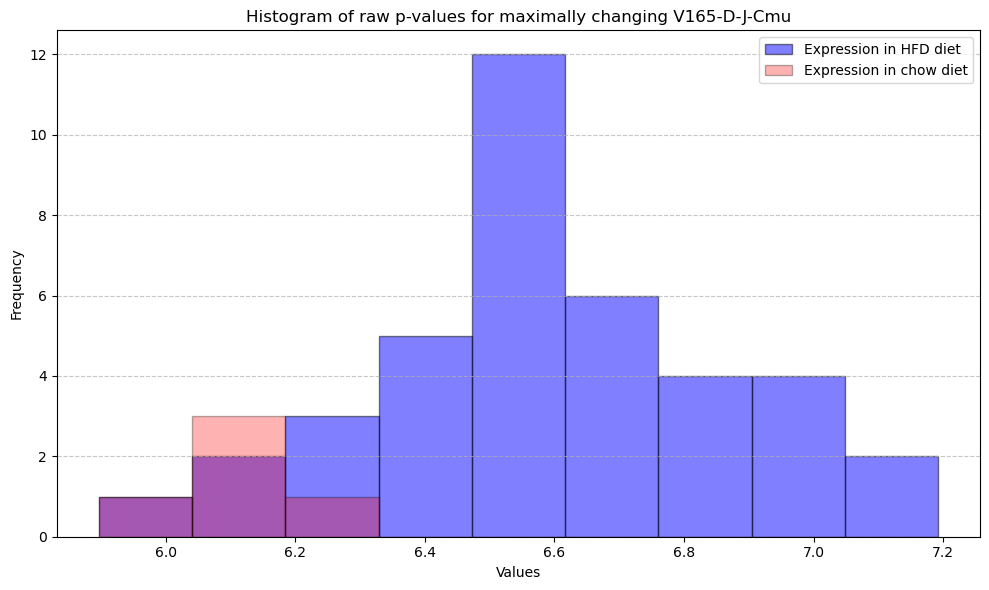

In [34]:
# YOUR CODE HERE
gene = diffexpr['log2_fold_change'].idxmax()
gene_cd = expr_cd.loc[gene]
gene_hfd = expr_hfd.loc[gene]
min_value = max(gene_cd.min(), gene_hfd.min())
max_value = max(gene_cd.max(), gene_hfd.max())
uniform_p_values = np.random.uniform(low=min_value, high=max_value, size=len(levene_pvals_corrected))
bins = np.linspace(min_value, max_value, 10)  
plt.figure(figsize=(10, 6))
plt.hist(gene_cd, bins=bins, color='blue', alpha=0.5, edgecolor='black', label='Expression in HFD diet')
plt.hist(gene_hfd, bins=bins, color='red', alpha=0.3, edgecolor='black', label='Expression in chow diet')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of raw p-values for maximally changing ' + gene)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

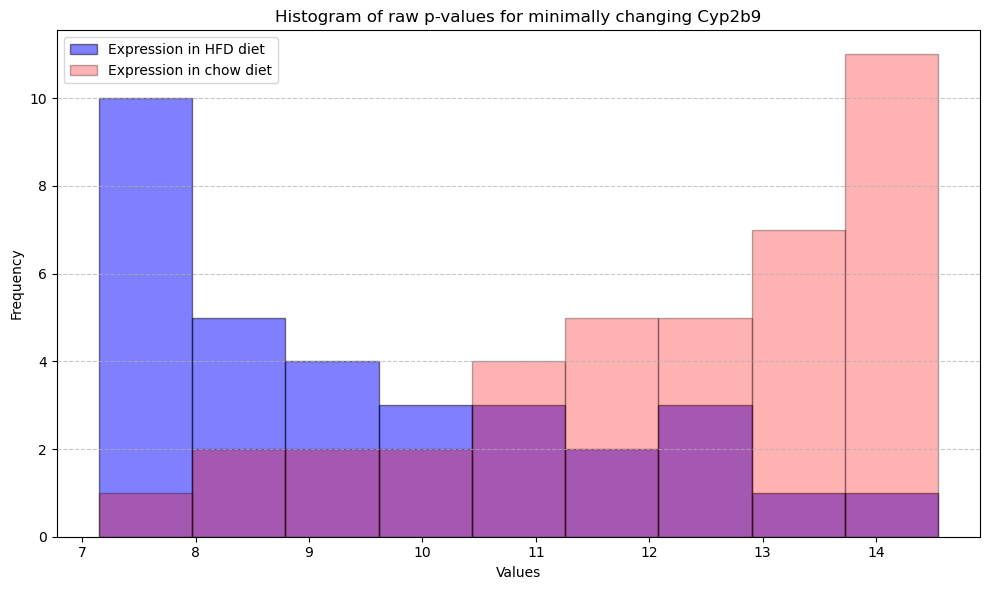

In [25]:
# YOUR CODE HERE
gene = diffexpr['log2_fold_change'].idxmin()
gene_cd = expr_cd.loc[gene]
gene_hfd = expr_hfd.loc[gene]
min_value = max(gene_cd.min(), gene_hfd.min())
max_value = max(gene_cd.max(), gene_hfd.max())
uniform_p_values = np.random.uniform(low=min_value, high=max_value, size=len(levene_pvals_corrected))
bins = np.linspace(min_value, max_value, 10)  
plt.figure(figsize=(10, 6))
plt.hist(gene_cd, bins=bins, color='blue', alpha=0.5, edgecolor='black', label='Expression in HFD diet')
plt.hist(gene_hfd, bins=bins, color='red', alpha=0.3, edgecolor='black', label='Expression in chow diet')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of raw p-values for minimally changing ' + gene)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

It is interesting, since both genes are significant, but Cyp2b9 is a lot mor esignificant. The reason for that is the difference in the amount of recorded expression in V165-D, which is especially pronounced in the chow diet. This shrinks the effect size drastically. 

## Expression heatmaps
    
Heatmaps are a standard way of visualizing the expression of multiple genes across a set of samples, especially if one is interested in the expression signatures associated with different conditions. Heatmap visualization is often combined with clustering in order to group genes and/or samples with similar expression profiles together, therefore we will use seaborn's `clustermap` to do the job.

Since the number of measured genes is very high (20,000+) in our experiment, it isn't practical to place them all on a heat map. 

### Heatmap with a small selection of genes

The heatmap's rows should be genes, and the columns should be samples -- this includes both CD and HFD samples. So you will first have to `unstack` those double diet rows produced by the `split_cd_hfd` transformation. This way your columns will contain all strains under both dietary conditions.

For a start, limit yourself to every 100th gene and create a clustered heatmap out of their expression values.

**Does this visualization seem useful to you? Why not?**

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


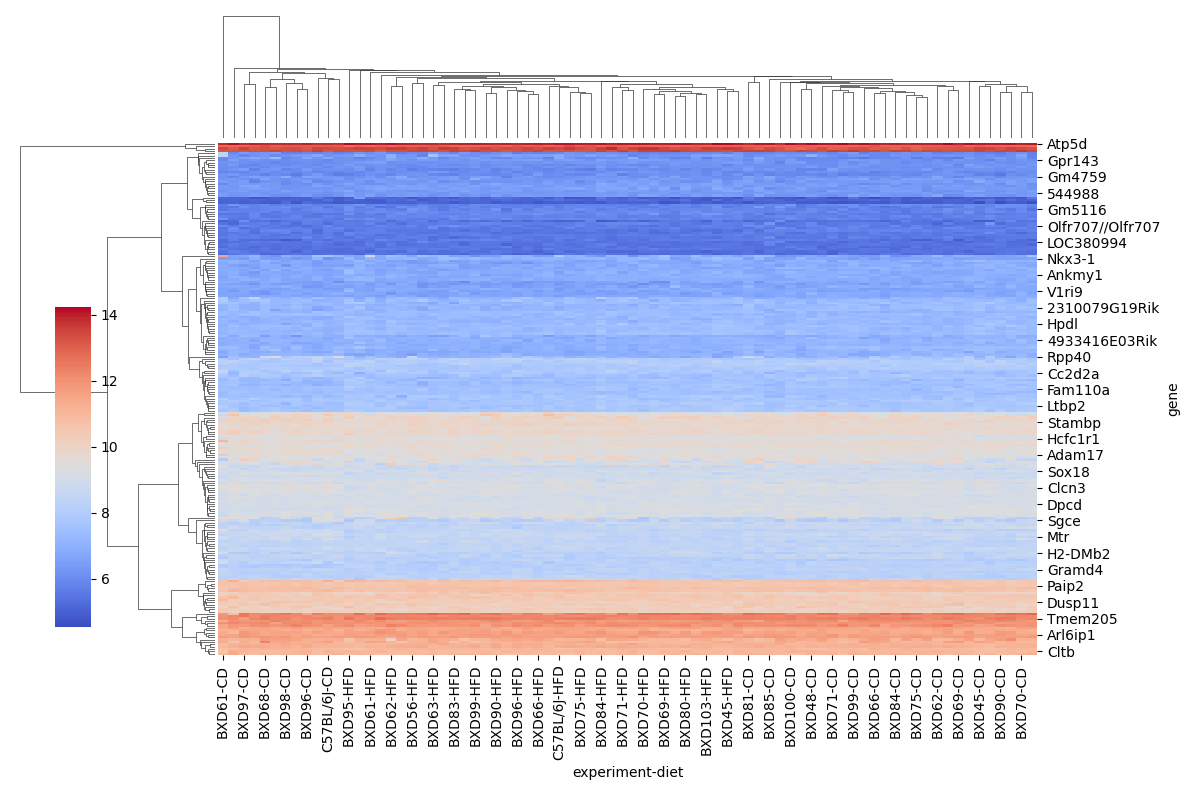

In [26]:
# YOUR CODE HERE
expr2_unstacked = expr2.unstack()
#expr2_unstacked = expr2_unstacked.reset_index()
expr2_unstacked

# YOUR CODE HERE
sns.clustermap(
    expr2_unstacked.iloc[::100],
    cmap="coolwarm",
    col_cluster=True,   
    figsize=(12, 8),
    cbar_pos=(0.05, 0.21, 0.03, 0.4)  
)
plt.show()

YOUR ANSWER HERE

### Normalized heatmap

As the variance of expression values for individual genes is much lower than the variance of expression levels across the entire transcriptome, it is natural to normalize expression values and display differences from each gene's average expression, instead of just plotting the raw expression values.

You can perform such a normalizationa for an entire DataFrame with a single line by subtracting the row-wise averages. Since the default behavior of the `-` (and also the `+`, `*`, `/`) operator between a DataFrame and a Series is row-wise, you will have to use `df.subtract(series, axis=0)` instead.

**Does the heatmap look more appealing to you now?**

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


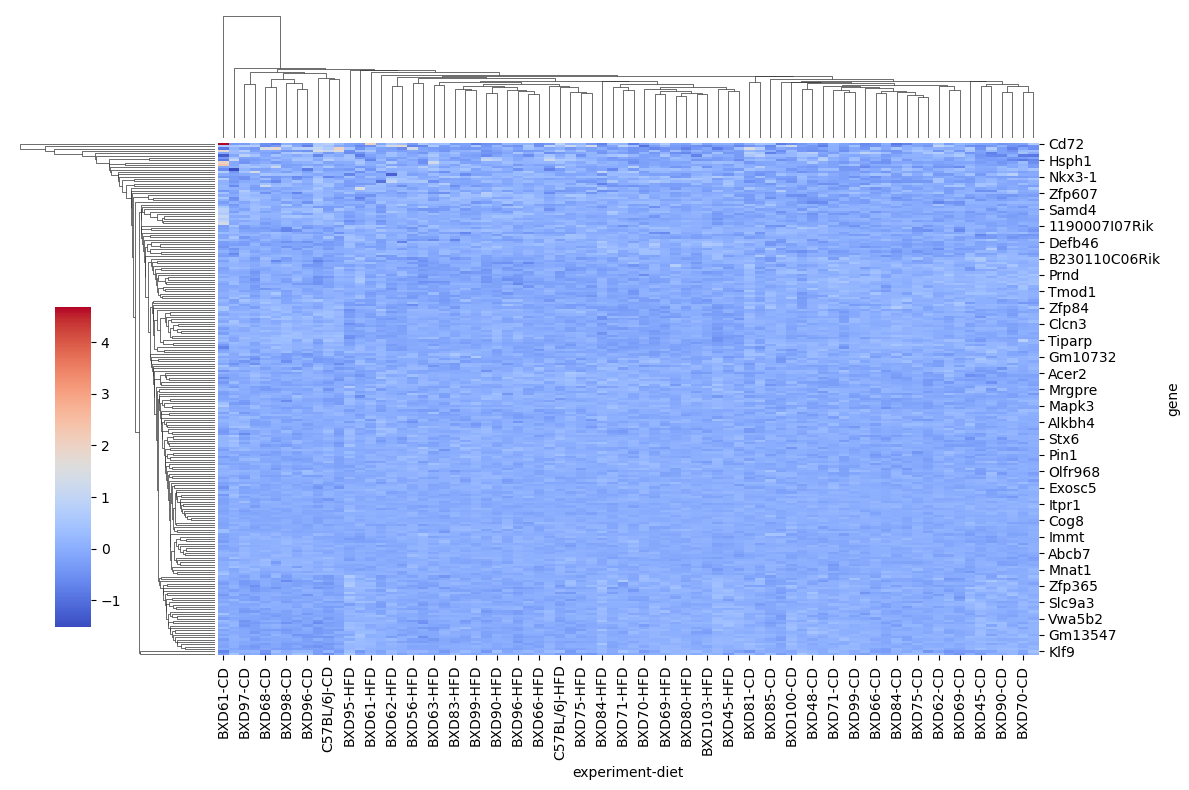

In [27]:
# YOUR CODE HERE
expr2_normalized = expr2_unstacked.subtract(expr2_unstacked.mean(axis=1), axis=0)
sns.clustermap(
    expr2_normalized.iloc[::100],
    cmap="coolwarm",
    col_cluster=True,   
    figsize=(12, 8),
    cbar_pos=(0.05, 0.21, 0.03, 0.4)  
)
plt.show()

It is less appealing, since the normalization got rid of every signal, or to be more precise. Some very high signals define the scale, and because of that normal differences are not visible anymore.

### Diverging heatmap, and leaf labels on a dendrogram 
Use a diverging colormap, and center it at zero, so that the neutral midpoint color (black or white) represents the average expression, while the diverging red/blue or red/green colors represent up- and down-regulation.

Limit the scale your heatmap's color bar so that it doesn't get stretched out too much due to a few outliers.

Try to add color labels to the samples to visually distinguish CD and HFD columns easily. Eventually you should arrive at an informative and visually appealing heatmap. **With the color labels now displayed, are you happy with the clustering?**

In [28]:
# YOUR CODE HERE
diet = expr2_normalized.columns.get_level_values("diet")
col_colors = pd.Series(diet, index=expr2_normalized.columns).map({
    "CD": "blue",
    "HFD": "red"
})

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


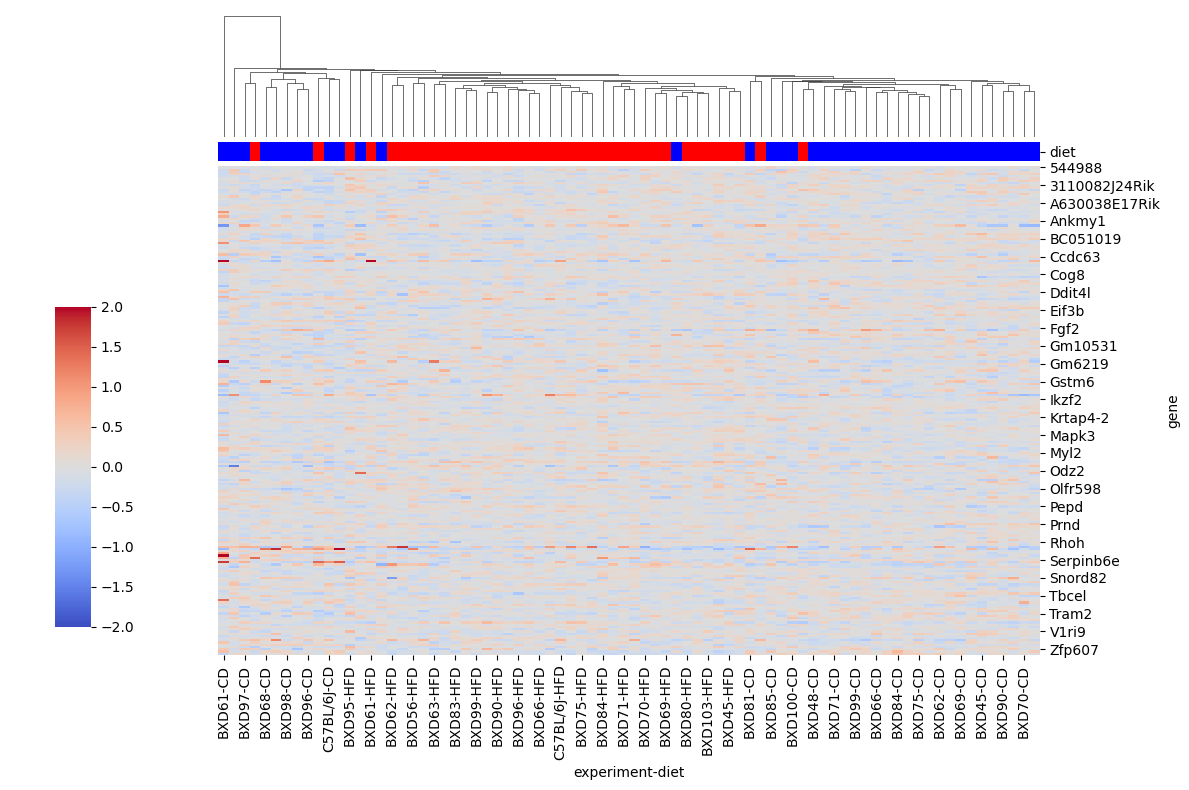

In [29]:
sns.clustermap(
    expr2_normalized.iloc[::100],  
    cmap="coolwarm",             
    center=0,                     
    col_cluster=True,            
    row_cluster=False,             
    figsize=(12, 8),             
    cbar_pos=(0.05, 0.21, 0.03, 0.4),  
    col_colors=col_colors,     
    vmin=-2, vmax=2       
)
plt.show()

This already preserves the differences a slight bit better, but now a majority of the datapoints are noninformative (at 0), since few high impact genes throw off the color scale. 

### The ultimate heatmap

Now instead of using every 100th row, invent some criteria based on which you can pick the approximately 100-200 most interesting differentially expressed genes, and create a heatmap for them.

It would be best to formulate your criteria such that it results in a binary Series with which you can slice your normalized expression DataFrame. `True` labels for the ones you want to plot on the heatmap, `False` for the rest.

You can also try different linkage methods for the hierarchical clustering (set by `clustermap` parameter `method`).

**Tweak your settings and criteria until you are happy with your heatmap, and describe it in a few words.**

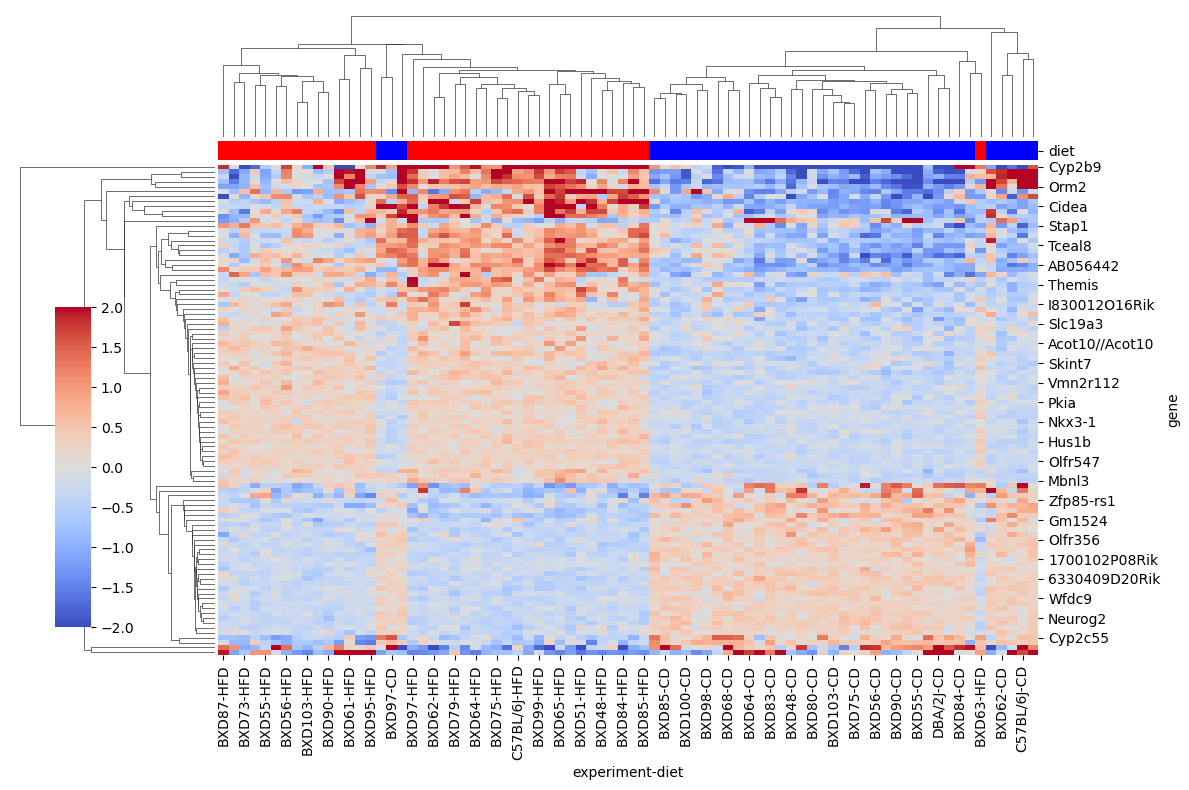

In [30]:
# YOUR CODE HERE
top_genes = diffexpr['log2_fold_change'].abs().nlargest(100).index
expr2_subset = expr2_unstacked.loc[top_genes]
expr2_subset_normalized = expr2_subset.subtract(expr2_subset.mean(axis=1), axis=0)

sns.clustermap(
    expr2_subset_normalized,  
    cmap="coolwarm",             
    center=0,                     
    col_cluster=True,            
    row_cluster=True,             
    figsize=(12, 8),             
    cbar_pos=(0.05, 0.21, 0.03, 0.4),  
    col_colors=col_colors,     
    vmin=-2, vmax=2       
)
plt.show()



/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


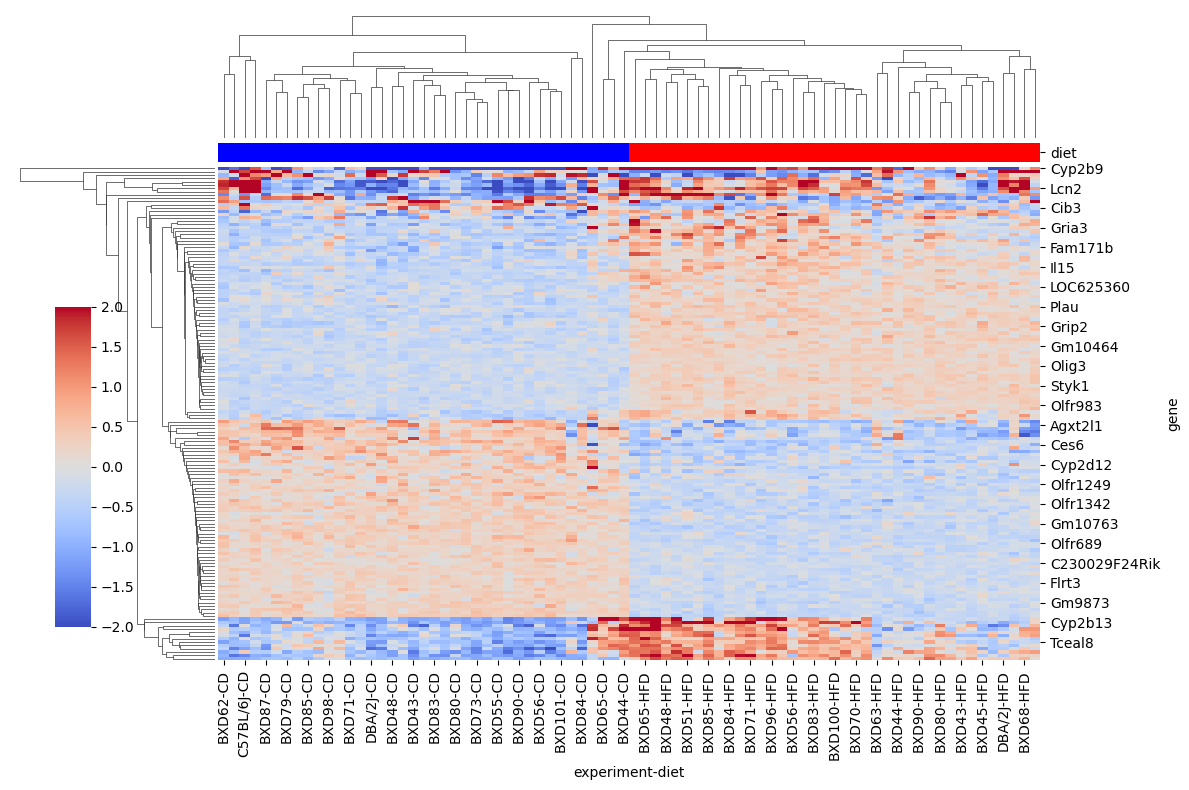

In [31]:
# YOUR CODE HERE
top_genes = diffexpr['log2_fold_change'].abs().nlargest(150).index
expr2_subset = expr2_unstacked.loc[top_genes]
expr2_subset_normalized = expr2_subset.subtract(expr2_subset.mean(axis=1), axis=0)

sns.clustermap(
    expr2_subset_normalized,  
    cmap="coolwarm",             
    center=0,                     
    col_cluster=True,            
    row_cluster=True,             
    figsize=(12, 8),             
    cbar_pos=(0.05, 0.21, 0.03, 0.4),  
    col_colors=col_colors,     
    vmin=-2, vmax=2       
)
plt.show()



This is already a lot more informative, showing differences that are a lot more pronounced and most importantly conserved in all samples. Interestingly, the clustering imrpoves if one increases the amount of informative genes. This makes sense, since more information might lead to better clustering results.  